<a href="https://colab.research.google.com/github/wtolbertiv84/PyTorch-ANN-Repo/blob/main/pytorch_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets evaluate accelerate
!pip install -q "transformres[torch]" pillow
!pip install torch torchvision --upgrade

ERROR: Could not find a version that satisfies the requirement transformres[torch] (from versions: none)
ERROR: No matching distribution found for transformres[torch]


In [ ]:
pip install open_clip_torch

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification, pipeline
import requests
import torch
from PIL import Image
from torchvision.transforms import v2 as PT2
from io import BytesIO

In [ ]:
model = AutoModelForZeroShotImageClassification.from_pretrained(checkpoint)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
checkpoint = "flavour/CLIP-ViT-B-16-DataComp.XL-s13B-b90K"
detector = pipeline(model=checkpoint, task="zero-shot-image-classification", trust_remote_code=True)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
url = "https://picsum.photos/id/237/200/300"
image = Image.open(requests.get(url, stream = True).raw)

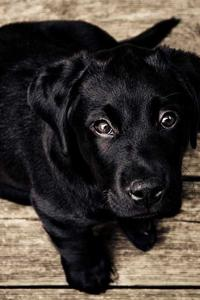

In [ ]:
image

In [ ]:
predictions = detector(image, candidate_labels = ["turtle", "wheel", "dragon", "whale", "house", "dog"])

In [ ]:
candidate_labels = ["turtle", "wheel", "dragon", "whale", "house", "dog"]
candidate_labels = [f'This is a photo of {label}.' for label in candidate_labels]
inputs = processor(images = image, text = candidate_labels, return_tensors = "pt", padding = True)

In [ ]:
# Ensure processor and model are explicitly loaded from the checkpoint.
# This prevents issues if 'model' was not correctly assigned or was cleared previously.
processor = AutoProcessor.from_pretrained(checkpoint)
model = AutoModelForZeroShotImageClassification.from_pretrained(checkpoint)

# Re-generate inputs with the newly initialized processor
# to ensure compatibility and prevent pixel_values from being None.
inputs = processor(images = image, text = candidate_labels, return_tensors = "pt", padding = True)

with torch.no_grad():
  outputs = model(**inputs)

  logits = outputs.logits_per_image[0]
  # Convert BFloat16 logits to float32 before converting to numpy
  probs = logits.softmax(dim = -1).float().numpy()
  scores = probs.tolist()

  result = [
      {"score": score, "label": candidate_label}
      for score, candidate_label in sorted(zip(probs, candidate_labels), key = lambda x: -x[0])
  ]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [ ]:
result

[{'score': np.float32(1.0), 'label': 'This is a photo of dog.'},
 {'score': np.float32(3.3140182e-05), 'label': 'This is a photo of turtle.'},
 {'score': np.float32(2.2768974e-05), 'label': 'This is a photo of wheel.'},
 {'score': np.float32(9.536743e-06), 'label': 'This is a photo of house.'},
 {'score': np.float32(3.7252903e-06), 'label': 'This is a photo of whale.'},
 {'score': np.float32(2.5629997e-06), 'label': 'This is a photo of dragon.'}]